In [2]:
#Implementing short term memory using memory saver which saves memory in RAM for that session
from langgraph.graph import StateGraph,START
from langgraph.graph.message import MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

Without CheckPointer: Demo

In [3]:
load_dotenv()

True

In [ ]:
#initializing model
model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [5]:
#call model node defined here
def call_model(state:MessagesState):
    response =  model.invoke(state['messages'])
    return {'messages':[response]}

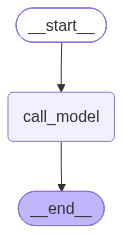

In [6]:
#building graph
builder = StateGraph(MessagesState)

builder.add_node("call_model",call_model)

builder.add_edge(START,"call_model")

graph = builder.compile()
graph

In [7]:
graph.invoke({"messages":[{"role":"user","content":"Hi iam Nazia"}]})

{'messages': [HumanMessage(content='Hi iam Nazia', additional_kwargs={}, response_metadata={}, id='b6197729-4d40-4118-8049-6979efa06255'),
  AIMessage(content="Hi Nazia! It's nice to meet you.\n\nI'm an AI assistant. How can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f7628-5a8a-72f3-b461-1277ab94b9c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 334, 'total_tokens': 339, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 307}})]}

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='d01bfcfb-94bd-467b-be3c-70c8e8540deb'),
  AIMessage(content="As an AI, I don't know your name or any personal information about you. I don't have memory of past conversations or access to your identity.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f7629-fd3c-7232-981b-3383ee5aae5f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 286, 'total_tokens': 292, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 253}})]}

Using CheckPointer - InMemorySaver to save in RAM

In [10]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
#havinga a checkpointer at every supersstep of the graph or workflow to keep track on state
graph = builder.compile(checkpointer=checkpointer)

In [11]:
config = {"configurable":{"thread_id":"thread-1"}}
config1 = {"configurable":{"thread_id":"thread-2"}}

In [12]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Naz."}]},config=config)

{'messages': [HumanMessage(content='Hi! My name is Naz.', additional_kwargs={}, response_metadata={}, id='68df88d5-86af-4939-ae09-6614b100b97e'),
  AIMessage(content="Hi Naz! It's great to meet you.\n\nHow can I help you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f7630-6dc7-7cd3-a700-a0136eb84321-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 107, 'total_tokens': 115, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 88}})]}

In [14]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config1)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='23a17178-4d38-48f0-b4cd-399a11381429'),
  AIMessage(content="As an AI, I don't have access to personal information about you, including your name. I don't know who you are.\n\nYou'll have to tell me!", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f7631-27eb-7683-895c-fcd968dacb2e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 373, 'total_tokens': 379, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 335}})]}

In [15]:
#to get the graph state at we have a func as we have added the checkpointer
snap = graph.get_state(config)
vals = snap.values
for msg in vals.get('messages',[]):
    print("-", type(msg).__name__, ":", msg.content)

- HumanMessage : Hi! My name is Naz.
- AIMessage : Hi Naz! It's great to meet you.

How can I help you today?
